# Baseline experiments

Run an experiment on the closed loop: edit the experiment cell, run all cells, read the table and the figures.

How the loop works, component by component, is `baseline_walkthrough.ipynb`. This notebook only runs experiments.


In [1]:
import os
import sys

notebook_directory = os.getcwd()
repo_from_notebook_directory = os.path.join(notebook_directory, "..", "..")
running_inside_baseline_folder = notebook_directory.endswith("baseline")
if running_inside_baseline_folder:
    REPO = os.path.abspath(repo_from_notebook_directory)
else:
    REPO = notebook_directory
sys.path.insert(0, REPO)
os.chdir(REPO)


def row_as_strings(row: dict, columns: list) -> list:
    """One table row: the row's value under each column, as text."""
    values = []
    for column in columns:
        value = row.get(column, "")
        values.append(str(value))
    return values


def column_widths(columns: list, cells: list) -> list:
    """Width of each column: its header or its widest cell."""
    widths = []
    for index, column in enumerate(columns):
        width = len(column)
        for row in cells:
            width = max(width, len(row[index]))
        widths.append(width)
    return widths


def aligned_line(values: list, widths: list) -> str:
    """One printed line: each value padded to its column width."""
    padded = []
    for value, width in zip(values, widths):
        padded.append(value.ljust(width))
    return "  ".join(padded)


def table(rows: list, columns: list) -> None:
    """Print rows (dicts) as an aligned text table with the given columns."""
    cells = []
    for row in rows:
        cells.append(row_as_strings(row, columns))
    widths = column_widths(columns, cells)
    rules = []
    for width in widths:
        rules.append("-" * width)
    print(aligned_line(columns, widths))
    print(aligned_line(rules, widths))
    for row in cells:
        print(aligned_line(row, widths))


print("repo:", REPO)


repo: /scratch/gpfs/MARTONOSI/sk2415/qlx-qec-sandbox/decsim


## 1. Choose the experiment

The whole experiment is one config. It starts from `baseline_closed_loop.yaml`, which holds every parameter: the circuit (code task, distance, rounds), the windowing scheme, every link latency, the decoder engine, the Pauli frame. Override only what this experiment changes.

`sweep` is a list of blocks. Each block runs the cross product of its three axes, `shots` seeds per point:

- a timing experiment: several `round_period_us`, few shots;
- a LER experiment: several `physical_error_probability`, many shots, one timing point;
- both blocks together: the standard full run.

Every shot reports timing and whether the logical prediction was wrong, so any block yields both kinds of numbers.


In [2]:
from experiments.baseline.baseline_closed_loop import DEFAULT_CONFIG, load_config

config = load_config(DEFAULT_CONFIG)

config["sweep"] = [
    {"physical_error_probability": [0.001],        # p on every physical operation (Stim's four channels)
     "round_period_us": [2.0, 1.0, 0.85, 0.5],     # input round period in us, slow to fast
     "algorithm_latency_us": [0.028],              # decoder card: 0.028, 0.28 or "measured"
     "shots": 5},                                  # seeds 0..shots-1 per point
]

# Everything else is a knob too, for example:
# config["windowing"]["scheme"] = "naive_online"   # no windowing: one decode per shot
# config["distance"] = 5
# config["links"]["cwd"]["latency_us"] = 1.0

config["report_dir"] = "experiments/results/notebook_experiment"

total_shots = 0
for block in config["sweep"]:
    points = len(block["physical_error_probability"])
    points *= len(block["round_period_us"])
    points *= len(block["algorithm_latency_us"])
    total_shots += points * block["shots"]
print("shots to run:", total_shots)


shots to run: 20


## 2. Run

`run_sweep` runs every shot through the whole loop (a point and seed named by two blocks runs once), `summarize` folds the shots into one row per sweep point, `write_report` writes `sweep.csv` and `sweep.md`, `plots` writes the figures the sweep supports.


In [3]:
from pathlib import Path

from experiments.baseline.baseline_closed_loop import run_sweep, summarize, write_report
from experiments.baseline.baseline_plots import plots

measurements = run_sweep(config)
rows = summarize(measurements)

report_dir = Path(config["report_dir"])
write_report(rows, report_dir)
plots(rows, report_dir)
print("report folder:", report_dir)


p 0.001, algorithm 0.028 us, round period 2.0 us: 5 shots done


p 0.001, algorithm 0.028 us, round period 1.0 us: 5 shots done


p 0.001, algorithm 0.028 us, round period 0.85 us: 5 shots done


p 0.001, algorithm 0.028 us, round period 0.5 us: 5 shots done


report folder: experiments/results/notebook_experiment


## 3. Read the numbers

One row per sweep point; the key columns below, every column in `sweep.csv`.

- `load`: serial chain service per window over window inter-arrival; above 1 the loop cannot keep up.
- `out/in`: decoded rounds per input round; 1 means keeping up.
- `ready->frame`: window complete in Buffer 0 to its correction committed in the Pauli frame.
- `qpu last->frame`: the same, but from the window's last round leaving the QPU (adds QC, controller, packing, C2B).
- `LER`: logical failures over shots; `vs PyMatching`: shots where the loop's prediction differs from whole-circuit PyMatching on the same events (tie-breaks only).


In [4]:
result_rows = []
for row in rows:
    input_rounds_per_us = 1 / row["round_period_us"]
    keeps_up = row["throughput_rounds_per_us"] / input_rounds_per_us
    result_rows.append({
        "p": row["physical_error_probability"],
        "card": row["algorithm_latency_us"],
        "round us": row["round_period_us"],
        "load": round(row["load"], 2),
        "out/in": round(keeps_up, 2),
        "ready->frame us": round(row["buffer0_ready_to_frame_median_us"], 3),
        "p99 us": round(row["buffer0_ready_to_frame_p99_us"], 3),
        "qpu last->frame us": round(row["qpu_last_round_to_frame_mean_us"], 3),
        "LER": f"{row['logical_failures']}/{row['shots']}",
        "vs PyMatching": row["prediction_mismatches_vs_direct"],
    })
columns = ["p", "card", "round us", "load", "out/in", "ready->frame us", "p99 us",
           "qpu last->frame us", "LER", "vs PyMatching"]
table(result_rows, columns)


p      card   round us  load  out/in  ready->frame us  p99 us  qpu last->frame us  LER  vs PyMatching
-----  -----  --------  ----  ------  ---------------  ------  ------------------  ---  -------------
0.001  0.028  2.0       0.25  1.0     2.06             2.06    3.56                0/5  0            
0.001  0.028  1.0       0.51  0.98    2.06             2.06    3.56                0/5  0            
0.001  0.028  0.85      0.6   0.98    2.06             2.06    3.56                0/5  0            
0.001  0.028  0.5       1.02  0.92    2.564            3.068   4.064               0/5  0            


## 4. Figures

One question each. The sweep figures appear only when more than one round period was swept, the LER figure only when more than one physical error rate was.

- `keep_up.png`: can it keep up?
- `reaction.png`: window ready to frame commit, median and p99.
- `backlog_<card>.png`: windows waiting over one shot, safe to overloaded.
- `one_window.png`: where one window's time goes.
- `ler.png`: logical error rate against physical error rate.


keep_up.png


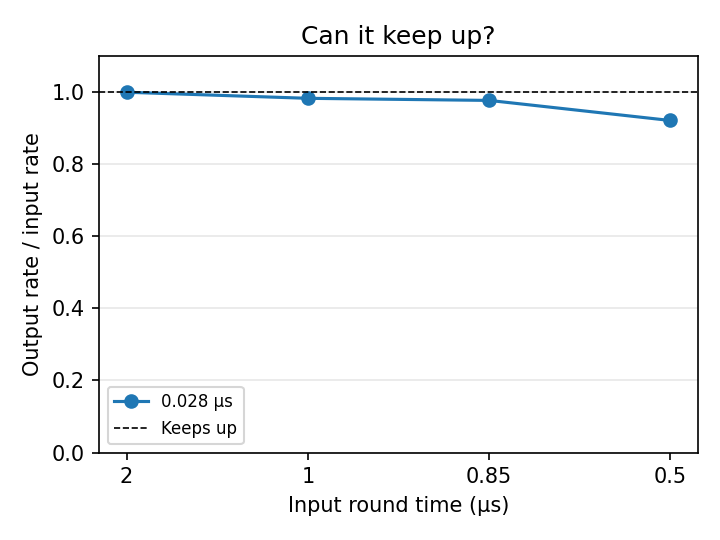

reaction.png


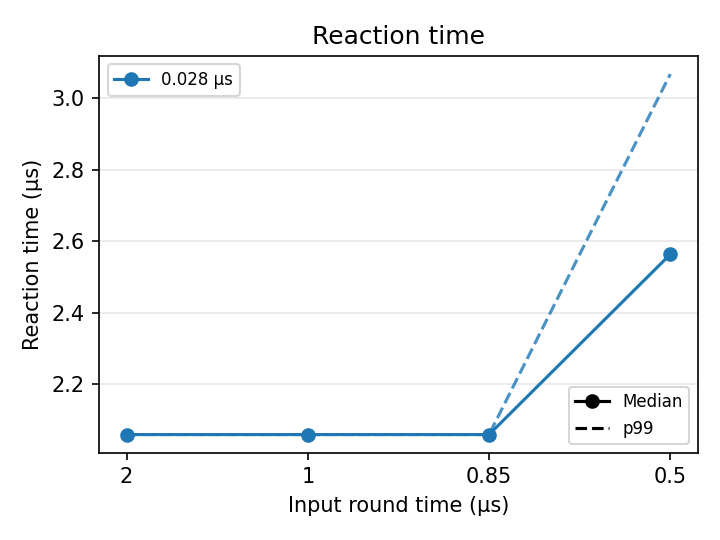

backlog_0.028us.png


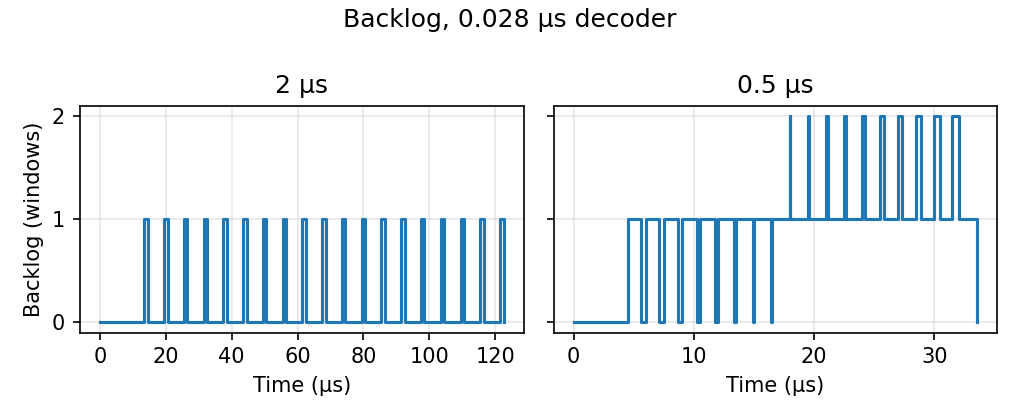

one_window.png


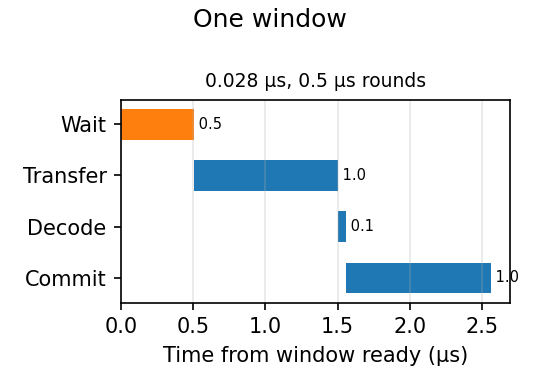

In [5]:
from IPython.display import Image, display

figure_names = ["keep_up.png", "reaction.png", "one_window.png", "ler.png"]
for row in rows:
    card = row["algorithm_latency_us"]
    card_file = card if isinstance(card, str) else f"{card:g}us"
    backlog_name = f"backlog_{card_file}.png"
    if backlog_name not in figure_names:
        figure_names.insert(2, backlog_name)

for name in figure_names:
    path = report_dir / name
    if path.exists():
        print(name)
        display(Image(filename=str(path)))


## The standard full experiment

The unedited yaml (both sweep blocks: 12 round periods x 3 cards for timing, 6 probabilities x 200 shots for LER) runs from the shell and writes `experiments/results/baseline_closed_loop/`:

    python -m experiments.baseline.baseline_closed_loop

The validation gates that back these numbers live in `experiments/validation/` (`guide/baseline-status.md` lists them all).
